### Import the Dataset

In [ ]:
with open("./datasets/names-v1.txt", 'r', encoding="utf-8") as file:
    dataset_content = file.read()

In [138]:
names = dataset_content.splitlines()

print(f"Number of names in the dataset: {len(names)}")
print(f"First 10 names in the dataset: {names[:10]}")

Number of names in the dataset: 32033
First 10 names in the dataset: ['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia', 'harper', 'evelyn']


### Extract All Unique Characters

In [139]:
chars = sorted(set(''.join(names)))

print(f"All Unique characters: {''.join([i if i != '\n' else '\\n' for i in chars])}")
print(f"Length: {len(chars)}")

All Unique characters: abcdefghijklmnopqrstuvwxyz
Length: 26


### Add Trigger Tokens

`<S>` : Start of the word

`<E>` : End of the word

In [140]:
start_token = "<S>"
end_token = "<E>"

chars.insert(0, start_token)
chars.insert(1, end_token)

print(f"All Unique characters: {''.join([i if i != '\n' else '\\n' for i in chars])}")
print(f"Length: {len(chars)}")

All Unique characters: <S><E>abcdefghijklmnopqrstuvwxyz
Length: 28


### Take Vocabulary Size (vocab_size)

Vocabulary size is the total number of unique characters in the dataset. It is important to determine the vocabulary size as it defines the dimensions of the bigram matrix and the one-hot encoding of characters.

In [141]:
vocab_size = len(chars)
print(f"Vocab size: {vocab_size}")

Vocab size: 28


### Character Tokenization: Encoding & Decoding | Create Mappings for Encoding and Decoding

To train a language model, text must be converted into numbers (**Encoding**) and turned back into text (**Decoding**). This is done using two complementary mappings: `stoi` (string-to-integer) and `itos` (integer-to-string).

| Process | Concept | Example | Purpose |
| --- | --- | --- | --- |
| **Encoding (`stoi`)** | Maps characters to unique index numbers. | 'a' $\rightarrow$ 0, 'b' $\rightarrow$ 1 | Converts text into numerical tensor inputs for the model. |
| **Decoding (`itos`)** | Maps index numbers back to characters. | 0 $\rightarrow$ 'a', 1 $\rightarrow$ 'b' | Converts the model's numerical outputs back into human-readable text. |

<br/>

$\text{"apple"} \xrightarrow{\text{Encode (stoi)}} [2, 4, 4, 6, 5] \xrightarrow{\text{Decode (itos)}} \text{"apple"}$

In [142]:
stoi = {char: index for index, char in enumerate(chars)} # string to integer -> map
itos = {index: char for index, char in enumerate(chars)} # integer to string -> map

print(f"stoi map: {stoi}")
print(f"itos map: {itos}")

stoi map: {'<S>': 0, '<E>': 1, 'a': 2, 'b': 3, 'c': 4, 'd': 5, 'e': 6, 'f': 7, 'g': 8, 'h': 9, 'i': 10, 'j': 11, 'k': 12, 'l': 13, 'm': 14, 'n': 15, 'o': 16, 'p': 17, 'q': 18, 'r': 19, 's': 20, 't': 21, 'u': 22, 'v': 23, 'w': 24, 'x': 25, 'y': 26, 'z': 27}
itos map: {0: '<S>', 1: '<E>', 2: 'a', 3: 'b', 4: 'c', 5: 'd', 6: 'e', 7: 'f', 8: 'g', 9: 'h', 10: 'i', 11: 'j', 12: 'k', 13: 'l', 14: 'm', 15: 'n', 16: 'o', 17: 'p', 18: 'q', 19: 'r', 20: 's', 21: 't', 22: 'u', 23: 'v', 24: 'w', 25: 'x', 26: 'y', 27: 'z'}


### Import PyTorch

In [143]:
import torch
import torch.nn.functional as F

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using: {torch.cuda.get_device_name(device) if device.type == 'cuda' else 'CPU'}")

torch.set_printoptions(sci_mode=False)
torch.set_printoptions(linewidth=400)

seed = 20060812

Using: NVIDIA GeForce RTX 4090


### Import Matplotlib

In [144]:
from matplotlib import pyplot as plt

---

# Neural Networks

Every neuron in a neural network possesses its own set of weights and a bias. The weights determine how much influence each input feature has on the neuron's output, while the bias serves as an offset that allows the neuron to shift its activation function. This shifting capability enables the network to model more complex, non-linear relationships in the data.

$$\text{Output} = \text{Activation}(\sum_{i=1}^{n} w_i x_i + b)$$


Below is a single-layer neural network that acts similarly to the bigram model. However, instead of directly calculating and counting explicit character frequencies from a table, this network learns to predict the next character based on the input character through iterative training.

In [145]:
# Training set of bigrams (x, y)

ix, iy = [], []

for name in names[:1]:
    characters = [start_token] + list(name) + [end_token]
    for ch1, ch2 in zip(characters, characters[1:]):
        x = stoi[ch1]
        y = stoi[ch2]

        ix.append(x)
        iy.append(y)


print(f"[Input Contexts]: {ix}")
print(f"[Predictions]   : {iy}\n")

[Input Contexts]: [0, 6, 14, 14, 2]
[Predictions]   : [6, 14, 14, 2, 1]



In [146]:
# Coverting to tensors
# The dtype SHOULD be int (because that what make sense for the indices of the characters in the vocabulary)
ix = torch.tensor(ix, dtype=torch.int64)
iy = torch.tensor(iy, dtype=torch.int64)

print(f"[Input Contexts]: {ix}")
print(f"[Predictions]   : {iy}\n")

[Input Contexts]: tensor([ 0,  6, 14, 14,  2])
[Predictions]   : tensor([ 6, 14, 14,  2,  1])



### Weights and Biases Initialization

Weights and biases are typically initialized with small random values to break symmetry across neurons, ensuring they calculate different gradients and learn effectively during backpropagation. Common initialization methods include:

**The Standard Normal Distribution:** Weights are drawn from a normal distribution with a mean of 0 and a standard deviation of 1.

![Standard Normal Distribution](./assets/standard_normal_distribution.png)



#### Weights Initialization

Weights are initialized with random values sampled from this standard normal distribution using `torch.randn`. The structural dimensions of the weight matrix are strictly governed by the input and output dimensions of the layer.

For a single-layer neural network that accepts a one-hot encoded input of size `vocab_size` and outputs predictions across that same vocabulary, the complete weight matrix requires a shape of `(vocab_size, vocab_size)`.

* **For a single neuron:** `W = torch.randn((vocab_size, 1))`
* **For multiple neurons:** `W = torch.randn((vocab_size, num_of_neurons))`


#### Activating Autograd Tracking (`requires_grad=True`)

When initializing parameters that the model must actively learn, we must explicitly append the configuration argument `requires_grad=True` to the tensor declaration:

```python
W = torch.randn((vocab_size, vocab_size), requires_grad=True)

```

This flag is critical for enabling backpropagation within the PyTorch:

* **Dynamic Graph Construction:** It instructs PyTorch’s `Autograd` engine to dynamically build a hidden computational graph behind the scenes. Every subsequent mathematical operation involving this tensor (such as matrix multiplication or exponentiation) is recorded as a connected node in a reverse execution chain.
* **Enabling `.backward()` Operations:** Without this flag, PyTorch treats the tensor as a static constant. Activating it ensures that when `loss.backward()` is triggered, the engine can execute the calculus chain rule in reverse, calculating the exact derivatives of the loss with respect to these weights.
* **Allocating Storage for Updates:** This setting instructs PyTorch to allocate and maintain a dedicated internal memory slot called `W.grad`. This slot acts as the instruction manual for your optimizer, holding the exact slopes needed to shift the parameter values during the gradient descent update step.



---

#### Why Neurons Scale Along the Columns

In matrix multiplication, the neuron count must map to the columns of the weight matrix due to strict dimensional compatibility rules. The inner dimensions of the operating matrices must match:

$$\text{Matrix Dimensions Matching: } \underbrace{(\text{pairs\_count} \times \text{vocab\_size})}_{\text{One-Hot Matrix (xenc)}} \times \underbrace{(\text{vocab\_size} \times \text{num\_of\_neurons})}_{\text{Weight Matrix (W)}}$$

Because the one-hot encoded input matrix has a shape of `(pairs_count, vocab_size)`, the weight matrix **must** position `vocab_size` along its rows to make the operation valid. This structural arrangement yields an output matrix of shape `(pairs_count, num_of_neurons)`, where each column isolates the specific, parallel output evaluations of a single neuron across the entire batch.

In [147]:
generator = torch.Generator().manual_seed(seed)
W = torch.randn((vocab_size, vocab_size), generator=generator, requires_grad=True)

torch.set_printoptions(sci_mode=False)
print(f"Neuron Weights: \n{W}\n")
print(f"Shape: {W.shape}")

Neuron Weights: 
tensor([[    -0.0475,      0.2805,      1.7291,     -1.1884,      1.1861,     -0.2548,      0.9014,     -0.0772,      0.1095,      1.3811,      0.1745,     -0.7251,      0.3100,      1.3356,     -2.2069,     -2.1703,      0.6170,     -0.0893,     -0.2111,      0.4560,     -0.0777,      1.1584,     -0.3117,      0.0696,      0.3249,     -1.3638,      0.1420,     -1.1101],
        [     0.0416,     -0.3323,      0.8993,     -0.2646,      0.6132,     -0.6978,     -1.3040,      0.5304,      0.5920,     -0.7581,     -0.2523,     -0.3089,     -0.4954,     -0.7376,      0.5873,     -0.7133,     -0.2036,     -1.0156,     -0.2494,     -0.2115,     -0.6346,      0.9358,     -0.4946,      0.4292,      0.6377,      0.2672,      0.3646,      0.2801],
        [    -0.9796,      0.2590,     -2.0933,     -1.4376,     -0.2372,      0.7665,     -1.5528,     -1.0119,      0.3985,     -0.2448,      0.6526,     -1.2662,      0.3815,      0.1484,     -1.2674,      0.5590,      1.9398,     -

Now we have `vocab_size` neurons, each with its own set of weights connecting it to the input layer.

## Forward Pass: From Logits to Probabilities via Softmax

The forward pass of a character-level bigram neural network processes a batch of data by mapping input tokens to raw scores, normalizing those scores into a probability distribution, and evaluating performance against target tokens.


#### 1. One-Hot Encode

We only one-hot encode the input index tensor (`ix`). The shape of this resulting input matrix is `(batch_size, vocab_size)`.


#### 2. Linear Projection to Logits

Multiplying our encoded inputs by the weight matrix $W$ projects the data into the logit space. This matrix multiplication acts as a deterministic selector: it plucks out the specific rows of $W$ that correspond to our input characters.


$$\text{logits} = xenc \times W \quad \implies \quad \text{Shape: } (\text{batch\_size}, \text{vocab\_size})$$


#### 3. Softmax Normalization


Normalization of each individual row in the logits matrix into a probability distribution where each row sums to 1. (Equivalent to the method we used to get `N_prob` from the bigram matrix `N`)

$$\text{probs} = \text{Softmax}(\text{logits}) \quad \implies \quad \text{Shape: } (\text{batch\_size}, \text{vocab\_size})$$


#### 4. Target Evaluation

To evaluate model performance, we use the target index tensor (`iy`) as a set of positional coordinate selectors.

By indexing into the `C_probs` matrix using the indices and the target column indices from `iy`, we pluck out the exact probability values the model assigned to the correct **next** characters. These target probabilities are then passed directly into our Average Negative Log-Likelihood (NLL) loss function.

$$\text{Target Probabilities} = \text{probs}[\text{row\_indices}, \text{iy}] \quad \implies \quad \text{Shape: } (\text{batch\_size})$$

---

### One-Hot Encoding

One-hot encoding is a technique used to represent categorical data as structural binary vectors. In the context of character-level language modeling, each unique character in the vocabulary is represented as a vector filled entirely with zeros, except for a single one located at the specific index corresponding to that character.

- **`0`**: Inactive state

- **`1`**: Active state


#### Why We Use One-Hot Encoding

Neural networks cannot perform meaningful continuous mathematics directly on raw nominal integers (such as treating a character as "index 14"). Passing raw integers would imply a numerical hierarchy that does not exist. One-hot encoding transforms these integers into a high-dimensional vector space, introducing two crucial mathematical properties:

- **Mathematical Isolation:** The `1` acts as a deterministic "selector" during matrix multiplication. When computing the dot product of a one-hot vector and a weight matrix ($xenc \times W$), the zeros cancel out all irrelevant parameters, effectively "plucking" one specific row out of that weight matrix to pass to the next step.

- **Equidistance:** In integer format, a model might interpret index 2 as being mathematically "closer" to index 3 than it is to index 25. One-hot encoding ensures that every single character vector is perfectly equidistant from every other character vector in the geometric space, eliminating artificial ordinal bias.


#### Example of One-Hot Encoding

Let the vocabulary be a 4-character set: `['a', 'b', 'c', 'd']` with a vector size of 4.

$$\begin{aligned} \text{'a' (index 0)} &\rightarrow [\mathbf{1}, 0, 0, 0] \\ \text{'b' (index 1)} &\rightarrow [0, \mathbf{1}, 0, 0] \\ \text{'c' (index 2)} &\rightarrow [0, 0, \mathbf{1}, 0] \\ \text{'d' (index 3)} &\rightarrow [0, 0, 0, \mathbf{1}] \end{aligned}$$


> NOTE:
>
> We one-hot encode the input indices (`ix`) but keep the target indices (`iy`) as raw integers. This asymmetry is determined by their distinct geometric roles in the forward and backward passes:
> * **Inputs (`ix` $\rightarrow$ Vectors):** Must be transformed into high-dimensional binary vectors (`xenc`) to physically interact with the weight matrix $W$ via matrix multiplication (`xenc @ W`).
> * **Targets (`iy` $\rightarrow$ Coordinates):** Remain as raw integers because they never undergo matrix multiplication. Instead, they serve as explicit column coordinates used to directly index into the Softmax probability matrix (`probs[rows, iy]`) to isolate the target values.
> 

---

#### PyTorch Implementation Constraint

The PyTorch function F.one_hot(...) does not feature a native dtype parameter. Consequently, it returns a tensor matching the data type of the input tensor, which is typically torch.int64 (long integers). Because neural network computations require floating-point operations for gradient tracking, we must explicitly cast the encoded tensor to torch.float32 by appending the .float() method immediately after the encoding call.

In [148]:
ixenc = F.one_hot(ix, num_classes=vocab_size).float()
iyenc = F.one_hot(iy, num_classes=vocab_size).float() # for visual representation, not used in the forward pass

print(f"[Input Contexts]: {ix}\n")
print(f"[One-Hot Encoded Input Contexts]:\n{ixenc}\n")
print(f"Shape: {ixenc.shape}\n\n")
print(f"[Targets]: {iy}\n")
print(f"[One-Hot Encoded Targets]:\n{iyenc}\n")
print(f"Shape: {iyenc.shape}\n")

[Input Contexts]: tensor([ 0,  6, 14, 14,  2])

[One-Hot Encoded Input Contexts]:
tensor([[1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]])

Shape: torch.Size([5, 28])


[Targets]: tensor([ 6, 14, 14,  2,  1])

[One-Hot Encoded Targets]:
tensor([[0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0.

Text(0.5, 1.0, 'One-Hot Encoded Input Contexts')

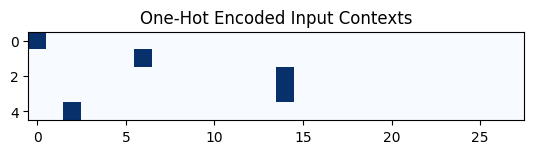

In [149]:
plt.imshow(ixenc, cmap='Blues')
plt.title("One-Hot Encoded Input Contexts")

Text(0.5, 1.0, 'One-Hot Encoded Predictions')

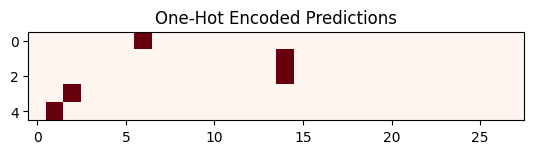

In [150]:
plt.imshow(iyenc, cmap='Reds')
plt.title("One-Hot Encoded Predictions")

### Logits Calculation

In [151]:
# 5, 28 x 28, 28
# result = 5, 28
logits = ixenc @ W # log counts

print(f"[Logits]: \n{logits}\n")
print(f"Shape: {logits.shape}")

[Logits]: 
tensor([[    -0.0475,      0.2805,      1.7291,     -1.1884,      1.1861,     -0.2548,      0.9014,     -0.0772,      0.1095,      1.3811,      0.1745,     -0.7251,      0.3100,      1.3356,     -2.2069,     -2.1703,      0.6170,     -0.0893,     -0.2111,      0.4560,     -0.0777,      1.1584,     -0.3117,      0.0696,      0.3249,     -1.3638,      0.1420,     -1.1101],
        [    -0.8178,     -1.5116,     -0.5274,      0.0991,     -0.2136,      1.6710,     -0.3363,     -0.2826,     -0.0005,     -0.2285,     -0.4033,      1.1066,      2.4902,      1.6548,      0.2062,     -1.2533,      1.3513,     -0.9735,      0.9232,     -3.4408,     -0.7078,     -0.2214,      0.2407,      0.2816,     -0.7274,      0.3138,     -0.4600,     -0.9008],
        [    -1.1429,      0.8026,     -2.0679,     -0.3624,      0.0816,     -0.7034,     -1.2959,     -1.4834,      0.3520,     -0.9982,      0.0515,      0.1443,      1.3120,     -0.8262,     -1.5906,     -0.2300,      0.2846,      0.3335

### Euler's Number ($e$)

Euler's number ($e \approx 2.71828$) is a fundamental mathematical constant that serves as the base of the natural logarithm ($\ln$). It is an irrational number, meaning it cannot be written as a simple fraction, and its decimal expansion continues infinitely without repeating patterns.

In deep learning, we frequently pass numbers through the exponential function, denoted as $\exp(x)$ or $e^x$. This function behaves predictably based on the sign of the input value:


- **Positive Inputs (Output is always $> 1$):** As positive inputs increase, the function scales upward exponentially toward infinity.

- **Negative Inputs (Output is always bounded between $0$ and $1$):** As negative inputs decrease, the function decays asymptotically toward zero, but will never cross or equal zero.


| Input Type | Mathematical Expression | Approximate Output Value | Visual Output Range |
| --- | --- | --- | --- |
| **Positive Numbers** | $\exp(1) = e^1$ | $2.71828\dots$ | Always above $1$ |
|  | $\exp(2) = e^2$ | $7.38905\dots$ |  |
|  | $\exp(3) = e^3$ | $20.08553\dots$ |  |
| **Zero Baseline** | $\exp(0) = e^0$ | $1.00000$ | Exact Anchor Point |
| **Negative Numbers** | $\exp(-1) = e^{-1}$ | $0.36788\dots$ | Always bounded between $0$ and $1$ |
|  | $\exp(-2) = e^{-2}$ | $0.13533\dots$ |  |
|  | $\exp(-3) = e^{-3}$ | $0.04979\dots$ |  |


![Exp(x)](./assets/eulers_exponential_function.png)

In [152]:
# C = counts
C = logits.exp() # equivalent to N matrix (frequency counts of bigrams)

### Softmax Function (Normalizing Logits into Probabilities)

To convert the raw outputs (logits) in the neural network layer into clear, interpretable predictions (probabilities), each row of the resulting matrix is normalized into a independent probability distribution. (Just like we computed probabilities in the bigram frequency matrix `N`)

This involves dividing each count in a row by the total sum of that row, ensuring that the probabilities across any given row add up to exactly $1.0$ (or approximately $1.0$ due to floating-point precision).

$$\text{Softmax}(x_i) = \frac{e^{x_i}}{\sum_{j=1}^{C} e^{x_j}} \quad \text{or} \quad \frac{C}{\text{C.sum(dim=1, keepdim=True)}} \quad \text{where} \quad C = logits.exp()$$

In [153]:
C_ROW_SUM = C.sum(1, keepdim=True)

C_probs = C / C_ROW_SUM # softmax

print(f"[Softmax Probabilities]: \n{C_probs}\n")
print(f"Shape: {C_probs.shape}\n")

[Softmax Probabilities]: 
tensor([[0.0227, 0.0315, 0.1342, 0.0073, 0.0779, 0.0185, 0.0586, 0.0220, 0.0266, 0.0947, 0.0283, 0.0115, 0.0325, 0.0905, 0.0026, 0.0027, 0.0441, 0.0218, 0.0193, 0.0376, 0.0220, 0.0758, 0.0174, 0.0255, 0.0329, 0.0061, 0.0274, 0.0078],
        [0.0092, 0.0046, 0.0123, 0.0231, 0.0169, 0.1112, 0.0149, 0.0158, 0.0209, 0.0166, 0.0140, 0.0632, 0.2523, 0.1094, 0.0257, 0.0060, 0.0808, 0.0079, 0.0526, 0.0007, 0.0103, 0.0168, 0.0266, 0.0277, 0.0101, 0.0286, 0.0132, 0.0085],
        [0.0092, 0.0641, 0.0036, 0.0200, 0.0312, 0.0142, 0.0079, 0.0065, 0.0409, 0.0106, 0.0302, 0.0332, 0.1067, 0.0126, 0.0059, 0.0228, 0.0382, 0.0401, 0.0155, 0.0362, 0.0435, 0.0695, 0.0928, 0.0181, 0.0518, 0.0605, 0.0135, 0.1009],
        [0.0092, 0.0641, 0.0036, 0.0200, 0.0312, 0.0142, 0.0079, 0.0065, 0.0409, 0.0106, 0.0302, 0.0332, 0.1067, 0.0126, 0.0059, 0.0228, 0.0382, 0.0401, 0.0155, 0.0362, 0.0435, 0.0695, 0.0928, 0.0181, 0.0518, 0.0605, 0.0135, 0.1009],
        [0.0112, 0.0387, 0.0037, 0.007

### Summery

In [154]:
print(f"[Input Contexts]\n")
print(f"Indices [ stoi ]: \n{ix}\n")
print(f"One-Hot Encoded [ ixenc = F.one_hot(ix) ]: \n{ixenc}\n")
print(f"Logits [ logits = ixenc @ W ]: \n{logits}\n")
print(f"Counts [ C = logits.exp() ]: \n{C}\n")
print(f"Softmax Probabilities [ C_prob = C / C.sum(1, keepdim=True) ]: \n{C_probs}\n")


print("[Input Contexts] | [Softmax Probabilities]\n")
for index, value in enumerate(ix):
    print(f"{value.item():<3} {f'({itos[value.item()]})':<13}|{C_probs[index, value.item()]:>24.4f}")

[Input Contexts]

Indices [ stoi ]: 
tensor([ 0,  6, 14, 14,  2])

One-Hot Encoded [ ixenc = F.one_hot(ix) ]: 
tensor([[1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]])

Logits [ logits = ixenc @ W ]: 
tensor([[    -0.0475,      0.2805,      1.7291,     -1.1884,      1.1861,     -0.2548,      0.9014,     -0.0772,      0.1095,      1.3811,      0.1745,     -0.7251,      0.3100,      1.3356,     -2.2069,     -2.1703,      0.6170,     -0.0893,   

### Target Evaluation and Loss Calculation

To evaluate model performance, we use the target index tensor (`iy`) as a set of positional coordinate selectors. By indexing into the `C_probs` matrix using the indices and the target column indices from `iy`, we pluck out the exact probability values the model assigned to the correct **next** characters. These target probabilities are then passed directly into our Average Negative Log-Likelihood (NLL) loss function.

$$\text{Target Probabilities} = \text{probs}[\text{indices\_of\_iy}, \text{values\_of\_iy}] \quad \implies \quad \text{Shape: } (\text{batch\_size})$$

In [155]:
iy

tensor([ 6, 14, 14,  2,  1])

In [156]:
# C_probs[0, 6], C_probs[1, 14], C_probs[2, 14], C_probs[3, 2], C_probs[4, 1]

Better way to do this is by passing a pre-defined matrix of indices and iy matrix directly to the slicing operation.

In [157]:
iy_indices = torch.arange(len(iy))
iy_indices

tensor([0, 1, 2, 3, 4])

In [158]:
iy_probs = C_probs[iy_indices, iy]
iy_probs

tensor([0.0586, 0.0257, 0.0059, 0.0036, 0.0387], grad_fn=<IndexBackward0>)

In [159]:
likelihood = iy_probs.prod()
log_likelihood = iy_probs.log().sum()
neg_log_likelihood = -log_likelihood
avg_neg_log_likelihood = neg_log_likelihood / len(iy_probs)


print(f"Likelihood: {likelihood:.4e}")
print(f"Log Likelihood: {log_likelihood:.4f}")
print(f"Negative Log Likelihood: {neg_log_likelihood:.4f}")
print(f"Average Negative Log Likelihood (loss): {avg_neg_log_likelihood:.4f}")

Likelihood: 1.2399e-09
Log Likelihood: -20.5082
Negative Log Likelihood: 20.5082
Average Negative Log Likelihood (loss): 4.1016


## Backward Pass (Backpropagation): Gradient Based Optimization

The backward pass reverses the operations of the forward pass, utilizing the calculus chain rule to compute how each parameter in the weight matrix $W$ contributed to the final scalar `loss`.


### In Forward Pass

```python
# 1. Initialize Weights
W = torch.randn((vocab_size, vocab_size), requires_grad=True)

# 2. Forward Operations
ixenc = F.one_hot(ix, num_classes=vocab_size).float()  # Input encoding
logits = ixenc @ W                                     # Raw scores (Logits)
C = logits.exp()                                       # Unnormalized counts
C_prob = C / C.sum(dim=1, keepdim=True)                # Softmax probabilities
iy_prob = C_prob[torch.arange(batch_size), iy]         # Isolate target probabilities

# 3. Calculate Loss
loss = -iy_prob.log().mean()                           # Average NLL Loss

```

When `loss.backward()` is called, PyTorch calculates gradients by executing a reverse chain reaction through each operation above.


#### 1. From Loss to Target Probabilities (`iy_prob.grad`)

* **Forward Operation:** `loss = -iy_prob.log().mean()`
* **Backward Action:** Backpropagation begins at the final scalar loss. The engine computes the derivative of the negative log function across the batch size. This calculates how a change in the isolated target probabilities impacts the final average error.


#### 2. From Target Probabilities to Full Probability Matrix (`C_prob.grad`)

* **Forward Operation:** `iy_prob = C_prob[torch.arange(batch_size), iy]`
* **Backward Action:** The gradient passes backward through the indexing operation. Because only the target column coordinates in `iy` were selected during the forward pass, the incoming error gradients are routed exclusively back into those specific matching column positions within the broader `C_prob` matrix.


#### 3. From Probabilities to Logits (`logits.grad`)

* **Forward Operation:** `C_prob = C / C.sum(dim=1, keepdim=True)` (Softmax operation)
* **Backward Action:** The gradient flows through the combined exponentiation and division steps of the Softmax layer. Because of the calculus properties of Softmax, the derivative simplifies cleanly down to a direct subtraction of the true targets from our predictions:

$$\text{logits.grad} = C\_prob - \text{targets}$$


#### 4. From Logits to Weights (`W.grad`)

* **Forward Operation:** `logits = ixenc @ W`
* **Backward Action:** The logit gradients arrive at the matrix multiplication layer. To find how the weights should change, the incoming `logits.grad` is multiplied by the transpose of the input matrix (`ixenc.T`). Because `ixenc` is one-hot encoded, this multiplication acts as a router, accumulating the final errors directly into the exact parameter rows of $W$ that generated the predictions.

$$\text{W.grad} = ixenc^T \times \text{logits.grad}$$


> NOTE:
>
> PyTorch deliberately destroys the backward graph the exact millisecond we call `.backward()`. This means that if we try to call `.backward()` again without re-running the forward pass, we will encounter an error because the computational graph has been freed from memory. To perform another backward pass, we must first execute the forward pass again to reconstruct the graph.

---

### Foward and Backward Pass Summary

| Forward Operator | Direct Mathematical Reverse Twin | Resulting Tensor Gradient | Role in Training |
| --- | --- | --- | --- |
| **`loss = ...`** | $\frac{\partial L}{\partial \text{iy\_prob}}$ | `iy_prob.grad` | Evaluates raw error of selected targets |
| **`C_prob / sum`** | $\text{probs} - \text{targets}$ | `logits.grad` | Measures prediction mistake for every vocabulary character |
| **`ixenc @ W`** | $ixenc^T \times \text{logits.grad}$ | `W.grad` | Maps the batch prediction mistakes back to the specific parameter rows of $W$ |

In [160]:
W.grad = None # set to zero gradient

loss = avg_neg_log_likelihood

print(f"[Before Backpropagation]\n")
print(f"Weights Gradient (W.grad | {W.grad.shape if W.grad is not None else 'N/A'}):\n{W.grad}\n")

loss.backward()

print("-" * 100)
print(f"\n[After Backpropagation]\n")
print(f"Weights Gradient (W.grad | {W.grad.shape if W.grad is not None else 'N/A'}):\n{W.grad}\n")

[Before Backpropagation]

Weights Gradient (W.grad | N/A):
None

----------------------------------------------------------------------------------------------------

[After Backpropagation]

Weights Gradient (W.grad | torch.Size([28, 28])):
tensor([[     0.0045,      0.0063,      0.0268,      0.0015,      0.0156,      0.0037,     -0.1883,      0.0044,      0.0053,      0.0189,      0.0057,      0.0023,      0.0065,      0.0181,      0.0005,      0.0005,      0.0088,      0.0044,      0.0039,      0.0075,      0.0044,      0.0152,      0.0035,      0.0051,      0.0066,      0.0012,      0.0055,      0.0016],
        [     0.0000,      0.0000,      0.0000,      0.0000,      0.0000,      0.0000,      0.0000,      0.0000,      0.0000,      0.0000,      0.0000,      0.0000,      0.0000,      0.0000,      0.0000,      0.0000,      0.0000,      0.0000,      0.0000,      0.0000,      0.0000,      0.0000,      0.0000,      0.0000,      0.0000,      0.0000,      0.0000,      0.0000],
        [ 

In [161]:
W.data -= 0.1 * W.grad # update weights using .data without letting auto-grad track this operation

## Forward & Backward Pass: The Training


We are now using the GPU to perform the forward and backward passes, which allows us to compute gradients and update the weights of our neural network efficiently. The training loop iteratively processes batches of data, computes the loss, and updates the model parameters using gradient descent.

In [162]:
# Training set of bigrams (x, y)

ix, iy = [], []

for name in names:
    characters = [start_token] + list(name) + [end_token]
    for ch1, ch2 in zip(characters, characters[1:]):
        x = stoi[ch1]
        y = stoi[ch2]

        ix.append(x)
        iy.append(y)


print(f"[Input Contexts Size]: {len(ix)}")
print(f"[Predictions Size]   : {len(iy)}\n")

[Input Contexts Size]: 228146
[Predictions Size]   : 228146



In [163]:
# Coverting to tensors
# The dtype SHOULD be int (because that what make sense for the indices of the characters in the vocabulary)
ix = torch.tensor(ix, dtype=torch.int64).to(device)
iy = torch.tensor(iy, dtype=torch.int64).to(device)

In [164]:
generator = torch.Generator().manual_seed(seed)
W = torch.randn((vocab_size, vocab_size), generator=generator).to(device)

# Auto-grad should turn on after setting up the weights tensor in a specified device (CPU or GPU)
W.requires_grad = True

W

tensor([[    -0.0475,      0.2805,      1.7291,     -1.1884,      1.1861,     -0.2548,      0.9014,     -0.0772,      0.1095,      1.3811,      0.1745,     -0.7251,      0.3100,      1.3356,     -2.2069,     -2.1703,      0.6170,     -0.0893,     -0.2111,      0.4560,     -0.0777,      1.1584,     -0.3117,      0.0696,      0.3249,     -1.3638,      0.1420,     -1.1101],
        [     0.0416,     -0.3323,      0.8993,     -0.2646,      0.6132,     -0.6978,     -1.3040,      0.5304,      0.5920,     -0.7581,     -0.2523,     -0.3089,     -0.4954,     -0.7376,      0.5873,     -0.7133,     -0.2036,     -1.0156,     -0.2494,     -0.2115,     -0.6346,      0.9358,     -0.4946,      0.4292,      0.6377,      0.2672,      0.3646,      0.2801],
        [    -0.9796,      0.2590,     -2.0933,     -1.4376,     -0.2372,      0.7665,     -1.5528,     -1.0119,      0.3985,     -0.2448,      0.6526,     -1.2662,      0.3815,      0.1484,     -1.2674,      0.5590,      1.9398,     -0.7181,     -1.36

In [165]:
for i in range(1000):

    # forward pass
    ixenc = F.one_hot(ix, num_classes=vocab_size).float()
    logits = ixenc @ W
    C = logits.exp()
    C_probs = C / C.sum(1, keepdim=True)

    iy_probs = C_probs[torch.arange(len(iy)), iy]

    # average negative log likelihood
    loss = -(iy_probs.log().mean()) + 0.01 * (W**2).mean() # adding L2 regularization to the loss function

    if (i + 1) % 50 == 0 or i == 0:
        print(f"Iteration {i+1:02d} | Loss: {loss.item():.4f}")

    # backward pass
    W.grad = None

    loss.backward()

    W.data += -50 * W.grad

Iteration 01 | Loss: 3.7744
Iteration 50 | Loss: 2.5143
Iteration 100 | Loss: 2.4925
Iteration 150 | Loss: 2.4867
Iteration 200 | Loss: 2.4844
Iteration 250 | Loss: 2.4833
Iteration 300 | Loss: 2.4827
Iteration 350 | Loss: 2.4823
Iteration 400 | Loss: 2.4821
Iteration 450 | Loss: 2.4819
Iteration 500 | Loss: 2.4818
Iteration 550 | Loss: 2.4817
Iteration 600 | Loss: 2.4817
Iteration 650 | Loss: 2.4817
Iteration 700 | Loss: 2.4816
Iteration 750 | Loss: 2.4816
Iteration 800 | Loss: 2.4816
Iteration 850 | Loss: 2.4816
Iteration 900 | Loss: 2.4816
Iteration 950 | Loss: 2.4815
Iteration 1000 | Loss: 2.4815


### Coming up L2 regularization

. . .

Now we have a trained neural network that can predict the next character in a sequence based on the input character. Now time to generate new words using the trained model!

In [168]:
# Generator is used for reproducibility, ensuring that the same output is generated each time the code is run.
generator = torch.Generator(device=device).manual_seed(seed)

generated_names = []
for i in range(20):
    ix = 0
    bucket = []

    while True:
        # BIGRAM MODEL
        # probs = N[ix]
        # print(f"probs: {probs} | sum: {probs.sum()}")

        # NEURAL NETWORK MODEL
        logits_row = W[ix]
        C = logits_row.exp()
        probs = C / C.sum()

        ix = torch.multinomial(probs, num_samples=1, replacement=True, generator=generator).item()
        # print(ix, itos[ix])

        # until it gives '<E>'
        if itos[ix] == end_token:
            break

        bucket.append(itos[ix])

    generated_names.append(''.join(bucket))

print('\n'.join(generated_names))

chvnnle
cahahans
lrha
rietnnahyelarulepteema
kan
kaivison
a
kalavesh
ammamil
beziasa
caumanelliely
mada
a
an
meves
se
ne
ahelenn
zey
leva
